# Network Visualization Notebook
### Cesar Hernandez
### July 10, 2025

In [18]:
# -----------------------------------------
# DO NOT EDIT THIS CELL
# -----------------------------------------
# The only exception is if you need to run "!pip install" to install a package prior to importing
# This cell loads the required Python packages

# This cell will read in the appropriate packages, as well as the dataset to be used in this assignment.

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


import urllib.request
import io
import zipfile

url = "http://www-personal.umich.edu/~mejn/netdata/football.zip"

sock = urllib.request.urlopen(url)  # open URL
s = io.BytesIO(sock.read())  # read into BytesIO "file"
sock.close()

zf = zipfile.ZipFile(s)  # zipfile object
txt = zf.read("football.txt").decode()  # read info file
gml = zf.read("football.gml").decode()  # read gml data
# throw away bogus first line with # from mejn files
gml = gml.split("\n")[1:]
G = nx.parse_gml(gml)  # parse gml data

In [19]:
# -----------------------------------------
# INSTRUCTIONS: TASK 1
# -----------------------------------------
# Calculate degree centrality and betweenness centrality for all nodes in G
# And place these into objects named "dc" and "bc"

# PLACE YOUR CODE HERE
# Degree centrality
dc = nx.degree_centrality(G)

# Betweenness Centrality
bc = nx.betweenness_centrality(G)

In [20]:
# -----------------------------------------
# INSTRUCTIONS: TASK 2
# -----------------------------------------
# Calculate median degree centrality and betweenness centrality
# And place these into objects named "dc_med" and "bc_med"

# PLACE YOUR CODE HERE
# Median Degree Centrality
dc_med = np.median(list(dc.values()))

# Median Betweenness Centrality
bc_med = np.median(list(bc.values()))

In [21]:
# -----------------------------------------
# INSTRUCTIONS: TASK 3
# -----------------------------------------
# Using "dc_med" create a subgraph that only includes nodes with degree centrality above the median degree centrality value
# And name this subgraph "dc_subg"

# PLACE YOUR CODE HERE
# Identify the nodes with degree centrality above the median degree centrality value using list comprehension
hidcnodes = [node for node, dcval in dc.items() if dcval > dc_med] 

# Creates the dc_subg subgraph
dc_subg = G.subgraph(hidcnodes).copy()

In [28]:
# -----------------------------------------
# INSTRUCTIONS: TASK 4
# -----------------------------------------
# Using "bc_med" create a subgraph that only includes nodes with betweenness centrality above the median betweenness centrality value 
# And name this subgraph "bc_subg"

# PLACE YOUR CODE HERE
# Identify the nodes with betweenness centrality above the median betweenness centrality value using list comprehension
hibcnodes = [node for node, bcval in bc.items() if bcval > bc_med] 

# Creates the bc_subg subgraph
bc_subg = G.subgraph(hibcnodes).copy()

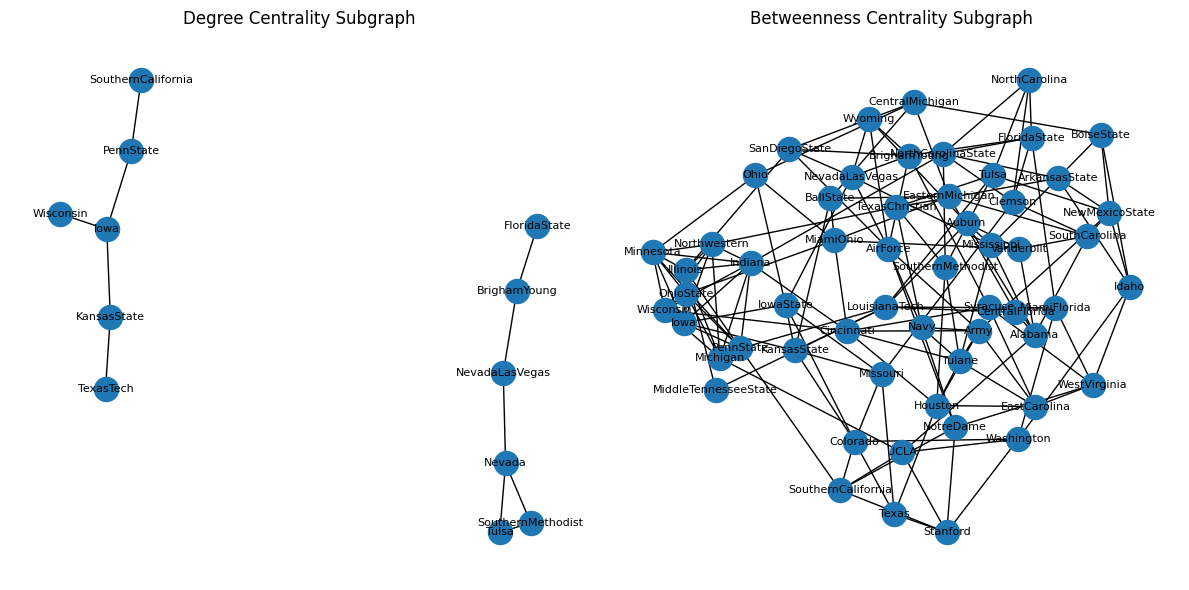

In [29]:
# -----------------------------------------
# INSTRUCTIONS: TASK 5
# -----------------------------------------
# Create and display a figure that visualizes both subgraphs side by side
# Degree centrality subgraph (dc_subg) on the left, and betweenness centrality subgraph (bc_subg) on the right

# PLACE YOUR CODE HERE
fig, ax = plt.subplots(1, 2, figsize=(12,6))
nx.draw(dc_subg, with_labels=True, font_size=8, ax=ax[0])
ax[0].set_title("Degree Centrality Subgraph")
nx.draw(bc_subg, with_labels=True, font_size=8, ax=ax[1])
ax[1].set_title("Betweenness Centrality Subgraph")
plt.tight_layout()

plt.show()